# Feature Engineering for `matchups.csv` (team-perspective long format)

Adapted for your refactored `matchups.csv` — the upstream builder now emits team-perspective long format directly (one row per `(GameID, TeamID)` view), with `Diff_*` columns and `Diff_Pythag_Win_Pct` already precomputed. So this notebook drops the old reshape and Four-Factors steps (those required raw `team_*` / `opp_*` values that no longer exist in the file) and just adds the chronological / matchup-context features that *can* be built from `(TeamID, OppID, Target_Win, DayDate)` plus the existing diffs.

### Pipeline

1. **Setup** — load and sanity
2. **Step 1** — Per-team chronological features (`Days_Rest`, `Is_B2B/3in4/4in5`, `Win_Streak`, `Last5/10_Win_Pct`, `Form_Gap_5/10`)
3. **Step 2** — Self-join for opponent versions and `Diff_*`
4. **Step 3** — Head-to-head
5. **Step 4** — Elo win prob, composite Power Rating, Pyth-Luck Gap, Altitude
6. **Step 5** — Save + curated `FEATURE_LIST` (≤ 50 columns)
7. **Sanity checks**

### What's already in your data (so I'm not recomputing it)

- Every season-aggregate `Diff_*`: `Diff_Net_Rating`, `Diff_Avg_Off_Eff`, `Diff_Avg_Def_Eff`, `Diff_Pregame_Elo`, `Diff_Win_Pct`, `Diff_Home/Away_Win_Pct`, `Diff_Last_14_Days_Win_Pct`, all the `Diff_Avg_*` counting stats.
- **`Diff_Pythag_Win_Pct`** — your upstream builder is already computing this (NBA Morey exponent).
- `Is_Home`, `TeamID`, `OppID`, `Target_Win`, `Diff_seed`.

### What I'm adding

- **Schedule density:** `Diff_Days_Rest`, `Team/Opp_Is_B2B/3in4/4in5`.
- **Form & streaks:** `Diff_Win_Streak`, `Diff_Last5/10_Win_Pct`, `Diff_Form_Gap_5/10` (recent rolling win-pct vs. season baseline).
- **Head-to-head:** `H2H_Win_Pct` for prior matchups vs same opponent this season.
- **Elo win prob:** standard logistic from `Diff_Pregame_Elo` + home-court bump.
- **Composite Power Rating:** `Diff_Net_Rating + 0.04 × Diff_Pregame_Elo`. Helps shallow XGBoost trees because it pre-combines two correlated strength signals.
- **Pyth-Luck Gap:** `Diff_Win_Pct − Diff_Pythag_Win_Pct`. Positive → this team is overperforming its Pythagorean expectation more than the opp; expect mean-reversion.
- **Altitude flags:** `Team/Opp_Altitude_Dis` for road games at Denver / Utah.

### A note on the writeups

I tried fetching the 3rd-place (`LR + Triple-Market Blend`) and 7th-place (`hedging for gardeners, gambling for masters`) writeups — Kaggle's Cloudflare gate blocked me from reading the actual content. From the titles: 3rd-place leans on betting-market consensus as a feature (you don't have market data), and 7th-place's title points at probability-output sharpening / risk hedging, which is post-prediction calibration rather than feature engineering. Neither directly transfers to features for your pipeline. The new features above are standard advanced-sports-prediction practice, not lifted from those specific writeups.

## Setup

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd

# ---- Config ----
INPUT_CSV         = "matchups.csv"
OUTPUT_CSV        = "matchups_v2.csv"
ELO_HOME_ADV      = 100.0     # Elo points for home court
ELO_TO_NETRATING  = 0.04      # 100 Elo gap ≈ 4 net-rating points
ALTITUDE_TEAM_IDS = {1610612743, 1610612762}  # Nuggets (Denver), Jazz (Salt Lake City)
OUT_DIR           = Path(".")
# ----------------

mm = pd.read_csv(INPUT_CSV, parse_dates=['DayDate'])
print(f"{INPUT_CSV}: {mm.shape}  ({mm['GameID'].nunique():,} games × 2 perspectives)")
print(f"Seasons: {sorted(mm['Season'].unique())}")
print(f"Has Diff_Pythag_Win_Pct: {'Diff_Pythag_Win_Pct' in mm.columns}")
print(f"Target_Win mean: {mm['Target_Win'].mean():.3f}  |  Is_Home mean: {mm['Is_Home'].mean():.3f}")

matchups.csv: (23958, 46)  (11,979 games × 2 perspectives)
Seasons: [np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025)]
Has Diff_Pythag_Win_Pct: True
Target_Win mean: 0.500  |  Is_Home mean: 0.500


## Step 1 — Per-team chronological features

Sort by `(TeamID, Season, DayDate, GameID)` and walk each team's chronological log. `shift(N)` ensures the current game's outcome never leaks into its own features.

In [2]:
def add_per_team_features(df: pd.DataFrame) -> pd.DataFrame:
    df = df.sort_values(['TeamID', 'Season', 'DayDate', 'GameID']).reset_index(drop=True).copy()
    grp_keys = ['TeamID', 'Season']

    # ---- Days_Rest + B2B / 3-in-4 / 4-in-5 ----
    prev_date  = df.groupby(grp_keys)['DayDate'].shift(1)
    df['Days_Rest'] = (df['DayDate'] - prev_date).dt.days.clip(upper=14)
    df['Is_B2B']    = (df['Days_Rest'] == 1).astype('Int64')
    df.loc[df['Days_Rest'].isna(), 'Is_B2B'] = pd.NA

    date_2_ago = df.groupby(grp_keys)['DayDate'].shift(2)
    df['Is_3in4'] = ((df['DayDate'] - date_2_ago).dt.days <= 3).astype('Int64')
    df.loc[date_2_ago.isna(), 'Is_3in4'] = pd.NA

    date_3_ago = df.groupby(grp_keys)['DayDate'].shift(3)
    df['Is_4in5'] = ((df['DayDate'] - date_3_ago).dt.days <= 4).astype('Int64')
    df.loc[date_3_ago.isna(), 'Is_4in5'] = pd.NA

    # ---- Win_Streak: +N for N-game win streak entering this game, -N for losses ----
    def streak(group):
        prev_won = group['Target_Win'].shift(1)
        s = 0; out = []
        for w in prev_won:
            if pd.isna(w):
                out.append(np.nan); s = 0
            elif w == 1:
                s = s + 1 if s >= 0 else 1
                out.append(s)
            else:
                s = s - 1 if s <= 0 else -1
                out.append(s)
        return pd.Series(out, index=group.index)

    df['Win_Streak'] = df.groupby(grp_keys, group_keys=False).apply(streak)

    # ---- Rolling last-N win pct (shift(1) so current outcome is excluded) ----
    def rolling_winpct(n):
        return (df.groupby(grp_keys)['Target_Win']
                  .apply(lambda s: s.shift(1).rolling(n, min_periods=1).mean())
                  .reset_index(level=grp_keys, drop=True))

    df['Last5_Win_Pct']  = rolling_winpct(5)
    df['Last10_Win_Pct'] = rolling_winpct(10)

    # ---- Season-to-date win pct (this team only) — needed for Form_Gap ----
    prior_wins  = df.groupby(grp_keys)['Target_Win'].cumsum() - df['Target_Win']
    prior_games = df.groupby(grp_keys).cumcount()
    season_to_date_wp = prior_wins / prior_games.replace(0, np.nan)

    df['Form_Gap_5']  = df['Last5_Win_Pct']  - season_to_date_wp
    df['Form_Gap_10'] = df['Last10_Win_Pct'] - season_to_date_wp

    return df


mm = add_per_team_features(mm)
mm[['Season','DayDate','TeamID','OppID','Target_Win',
    'Days_Rest','Is_B2B','Is_3in4','Is_4in5','Win_Streak',
    'Last5_Win_Pct','Last10_Win_Pct','Form_Gap_5','Form_Gap_10']].head(12)

C:\Users\Furag\AppData\Local\Temp\ipykernel_2368\999416705.py:34: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df['Win_Streak'] = df.groupby(grp_keys, group_keys=False).apply(streak)


,Season,DayDate,TeamID,OppID,Target_Win,Days_Rest,Is_B2B,Is_3in4,Is_4in5,Win_Streak,Last5_Win_Pct,Last10_Win_Pct,Form_Gap_5,Form_Gap_10
0,2016,2016-10-27,1610612737,1610612764,1,NaN,<NA>,<NA>,<NA>,NaN,NaN,NaN,NaN,NaN
1,2016,2016-10-29,1610612737,1610612755,1,2.0,0,<NA>,<NA>,1.0,1.00,1.000000,0.000000,0.000000
2,2016,2016-10-31,1610612737,1610612758,1,2.0,0,0,<NA>,2.0,1.00,1.000000,0.000000,0.000000
3,2016,2016-11-02,1610612737,1610612747,0,2.0,0,0,0,3.0,1.00,1.000000,0.000000,0.000000
4,2016,2016-11-04,1610612737,1610612764,0,2.0,0,0,0,-1.0,0.75,0.750000,0.000000,0.000000
5,2016,2016-11-05,1610612737,1610612745,1,1.0,1,1,0,-2.0,0.60,0.600000,0.000000,0.000000
6,2016,2016-11-08,1610612737,1610612739,1,3.0,0,0,0,1.0,0.60,0.666667,-0.066667,0.000000
7,2016,2016-11-09,1610612737,1610612741,1,1.0,1,0,0,2.0,0.60,0.714286,-0.114286,0.000000
8,2016,2016-11-12,1610612737,1610612755,1,3.0,0,0,0,3.0,0.60,0.750000,-0.150000,0.000000
9,2016,2016-11-15,1610612737,1610612748,1,3.0,0,0,0,4.0,0.80,0.777778,0.022222,0.000000


## Step 2 — Self-join for opponent values and `Diff_*`

Each row's opponent counterparts live in a different row of the same DataFrame (the other team's perspective on the same game). We rebuild them via a self-join on `(GameID, OppID → TeamID)`, then compute `Diff_* = team − opp` for the continuous features and keep the binary B2B/3in4/4in5 flags per perspective.

In [3]:
PER_TEAM_NEW = ['Days_Rest', 'Is_B2B', 'Is_3in4', 'Is_4in5',
                'Win_Streak', 'Last5_Win_Pct', 'Last10_Win_Pct',
                'Form_Gap_5', 'Form_Gap_10']

opp_lookup = (mm[['GameID', 'TeamID'] + PER_TEAM_NEW]
              .rename(columns={'TeamID': 'OppID',
                               **{c: f'Opp_{c}' for c in PER_TEAM_NEW}}))

mm = mm.merge(opp_lookup, on=['GameID', 'OppID'], how='left')

# Diff versions of the continuous chronological features
mm['Diff_Days_Rest']      = mm['Days_Rest']      - mm['Opp_Days_Rest']
mm['Diff_Win_Streak']     = mm['Win_Streak']     - mm['Opp_Win_Streak']
mm['Diff_Last5_Win_Pct']  = mm['Last5_Win_Pct']  - mm['Opp_Last5_Win_Pct']
mm['Diff_Last10_Win_Pct'] = mm['Last10_Win_Pct'] - mm['Opp_Last10_Win_Pct']
mm['Diff_Form_Gap_5']     = mm['Form_Gap_5']     - mm['Opp_Form_Gap_5']
mm['Diff_Form_Gap_10']    = mm['Form_Gap_10']    - mm['Opp_Form_Gap_10']

# Binary features kept per-perspective
mm = mm.rename(columns={'Is_B2B':  'Team_Is_B2B',
                         'Is_3in4': 'Team_Is_3in4',
                         'Is_4in5': 'Team_Is_4in5'})

# Drop the per-team intermediates (we keep diffs and the binary flags per perspective)
mm = mm.drop(columns=['Days_Rest', 'Win_Streak',
                      'Last5_Win_Pct', 'Last10_Win_Pct',
                      'Form_Gap_5', 'Form_Gap_10',
                      'Opp_Days_Rest', 'Opp_Win_Streak',
                      'Opp_Last5_Win_Pct', 'Opp_Last10_Win_Pct',
                      'Opp_Form_Gap_5', 'Opp_Form_Gap_10'])

mm[['TeamID','OppID',
    'Team_Is_B2B','Opp_Is_B2B','Team_Is_3in4','Opp_Is_3in4','Team_Is_4in5','Opp_Is_4in5',
    'Diff_Days_Rest','Diff_Win_Streak',
    'Diff_Last5_Win_Pct','Diff_Last10_Win_Pct',
    'Diff_Form_Gap_5','Diff_Form_Gap_10']].head(8)

,TeamID,OppID,Team_Is_B2B,Opp_Is_B2B,Team_Is_3in4,Opp_Is_3in4,Team_Is_4in5,Opp_Is_4in5,Diff_Days_Rest,Diff_Win_Streak,Diff_Last5_Win_Pct,Diff_Last10_Win_Pct,Diff_Form_Gap_5,Diff_Form_Gap_10
0,1610612737,1610612764,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,NaN,NaN,NaN,NaN,NaN,NaN
1,1610612737,1610612755,0,0,<NA>,<NA>,<NA>,<NA>,-1.0,2.0,1.000000,1.000000,0.000000,0.0
2,1610612737,1610612758,0,0,0,0,<NA>,0,0.0,1.0,0.333333,0.333333,0.000000,0.0
3,1610612737,1610612747,0,1,0,1,0,0,1.0,6.0,0.750000,0.750000,0.000000,0.0
4,1610612737,1610612764,0,0,0,0,0,0,0.0,2.0,0.750000,0.750000,0.000000,0.0
5,1610612737,1610612745,1,0,1,0,0,0,-2.0,-3.0,0.000000,0.000000,0.000000,0.0
6,1610612737,1610612739,0,0,0,0,0,0,0.0,-5.0,-0.400000,-0.333333,-0.066667,0.0
7,1610612737,1610612741,1,0,0,0,0,0,-1.0,1.0,0.200000,0.142857,0.057143,0.0


## Step 3 — Head-to-head this season

This team's prior win pct vs that specific opponent within the season. NaN means it's the first meeting.

In [4]:
def add_h2h(df: pd.DataFrame) -> pd.DataFrame:
    df = df.sort_values(['Season','TeamID','OppID','DayDate','GameID']).reset_index(drop=True).copy()
    grp = df.groupby(['Season','TeamID','OppID'], sort=False)
    cum_wins  = grp['Target_Win'].cumsum() - df['Target_Win']
    cum_games = grp.cumcount()
    df['H2H_Win_Pct'] = cum_wins / cum_games.replace(0, np.nan)
    return df


mm = add_h2h(mm)
mm[['Season','DayDate','TeamID','OppID','Target_Win','H2H_Win_Pct']].head(15)

,Season,DayDate,TeamID,OppID,Target_Win,H2H_Win_Pct
0,2016,2017-01-13,1610612737,1610612738,0,NaN
1,2016,2017-02-27,1610612737,1610612738,1,0.000000
2,2016,2017-04-06,1610612737,1610612738,1,0.500000
3,2016,2016-11-08,1610612737,1610612739,1,NaN
4,2016,2017-03-03,1610612737,1610612739,0,1.000000
5,2016,2017-04-07,1610612737,1610612739,1,0.500000
6,2016,2017-04-09,1610612737,1610612739,1,0.666667
7,2016,2016-11-22,1610612737,1610612740,0,NaN
8,2016,2017-01-05,1610612737,1610612740,1,0.000000
9,2016,2016-11-09,1610612737,1610612741,1,NaN


## Step 4 — Elo win prob, composite Power Rating, Pyth-Luck Gap, Altitude

All four are simple closed-form features computed directly from the existing `Diff_*` columns:

- **`Elo_Win_Prob`** = $1 / (1 + 10^{-(\text{Diff\_Pregame\_Elo} + \text{HCA}_{\text{signed}}) / 400})$ where HCA is +100 for the home team, −100 for the away team.
- **`Diff_Power_Rating`** = `Diff_Net_Rating + 0.04 × Diff_Pregame_Elo`. Pre-combines two correlated strength signals into one stronger feature for shallow trees.
- **`Diff_Pyth_Luck_Gap`** = `Diff_Win_Pct − Diff_Pythag_Win_Pct`. Positive means this team is overperforming its Pythagorean expectation more than the opp — expect mean-reversion.
- **`Team/Opp_Altitude_Dis`** flag for road games where the home team is at Denver or Utah.

In [5]:
# Elo win prob
hca = np.where(mm['Is_Home'].astype(bool), ELO_HOME_ADV, -ELO_HOME_ADV)
mm['Elo_Win_Prob'] = 1.0 / (1.0 + 10 ** (-((mm['Diff_Pregame_Elo'] + hca)) / 400.0))

# Composite power rating (from diffs only — no team_/opp_ values needed)
mm['Diff_Power_Rating'] = mm['Diff_Net_Rating'] + ELO_TO_NETRATING * mm['Diff_Pregame_Elo']

# Pythagorean luck gap: how much actual Win_Pct differs from Pythagorean expectation
mm['Diff_Pyth_Luck_Gap'] = mm['Diff_Win_Pct'] - mm['Diff_Pythag_Win_Pct']

# Altitude flags
mm['Team_Altitude_Dis'] = ((mm['Is_Home'] == 0) & mm['OppID'].isin(ALTITUDE_TEAM_IDS)).astype('Int8')
mm['Opp_Altitude_Dis']  = ((mm['Is_Home'] == 1) & mm['TeamID'].isin(ALTITUDE_TEAM_IDS)).astype('Int8')

print(f"Elo_Win_Prob: home rows mean = {mm.loc[mm['Is_Home']==1,'Elo_Win_Prob'].mean():.3f}  "
      f"(should be > 0.5)")
print(f"             away rows mean = {mm.loc[mm['Is_Home']==0,'Elo_Win_Prob'].mean():.3f}  "
      f"(should be < 0.5)")
print(f"\nDiff_Power_Rating  range: [{mm['Diff_Power_Rating'].min():.2f}, {mm['Diff_Power_Rating'].max():.2f}]")
print(f"Diff_Pyth_Luck_Gap range: [{mm['Diff_Pyth_Luck_Gap'].min():.3f}, {mm['Diff_Pyth_Luck_Gap'].max():.3f}]")
print(f"\nAltitude games: {((mm['Team_Altitude_Dis']==1) | (mm['Opp_Altitude_Dis']==1)).sum()//2} "
      f"(over {mm['Season'].nunique()} seasons)")

Elo_Win_Prob: home rows mean = 0.624  (should be > 0.5)
             away rows mean = 0.376  (should be < 0.5)

Diff_Power_Rating  range: [-52.97, 52.97]
Diff_Pyth_Luck_Gap range: [-0.660, 0.660]

Altitude games: 800 (over 10 seasons)


## Step 5 — Save + curated `FEATURE_LIST` (50 columns)

The list below is hand-curated to fit the 50-feature cap and prioritise signal density. Use `feature_cols = FEATURE_LIST` in your training cell.

**Cuts I made** (relative to a kitchen-sink list of 57+ available columns):
- `Diff_Overall_Win_Pct` — identical values to `Diff_Win_Pct` in your data (upstream sets one equal to the other), so dropping the duplicate.
- `Diff_seed` — within-season win-pct rank; ~98 % redundant with `Diff_Win_Pct` for NBA.
- `Diff_Avg_FGM` and `Diff_Avg_Opp_FGM` — strongly redundant with the (FGA, FGM3) pair on each side.
- `Diff_Avg_FTM` and `Diff_Avg_Opp_FTM` — ~95 % correlated with the corresponding FTA columns.
- `Diff_Avg_PF` and `Diff_Avg_Opp_PF` — referee-noise dominated, weak signal.

In [8]:
FEATURE_LIST = [
    # --- Strength (8) ---
    'Elo_Win_Prob', 'Diff_Pregame_Elo', 'Diff_Power_Rating',
    'Diff_Pythag_Win_Pct', 'Diff_Pyth_Luck_Gap',
    'Diff_Net_Rating', 'Diff_Avg_Off_Eff', 'Diff_Avg_Def_Eff',

    # --- Win pcts (4) ---
    'Diff_Win_Pct', 'Diff_Home_Win_Pct', 'Diff_Away_Win_Pct',
    'Diff_Last_14_Days_Win_Pct',

    # --- Form / momentum (5) ---
    'Diff_Win_Streak', 'Diff_Last5_Win_Pct', 'Diff_Last10_Win_Pct',
    'Diff_Form_Gap_5', 'Diff_Form_Gap_10',

    # --- Head-to-head + game context (5) ---
    'Is_Home', 'Team_Altitude_Dis', 'Opp_Altitude_Dis',
    'Diff_Avg_Score',

    # --- Schedule density (7) ---
    'Diff_Days_Rest',
    'Team_Is_B2B', 'Opp_Is_B2B',
    'Team_Is_3in4', 'Opp_Is_3in4',
    'Team_Is_4in5', 'Opp_Is_4in5',

    # --- Offensive counting (10) ---
    'Diff_Avg_FGA', 'Diff_Avg_FGM3', 'Diff_Avg_FGA3', 'Diff_Avg_FTA',
    'Diff_Avg_OR', 'Diff_Avg_DR',
    'Diff_Avg_Ast', 'Diff_Avg_TO', 'Diff_Avg_Stl', 'Diff_Avg_Blk',

    # --- Defensive counting (11) ---
    'Diff_Avg_Opp_Score',
    'Diff_Avg_Opp_FGA', 'Diff_Avg_Opp_FGM3', 'Diff_Avg_Opp_FGA3', 'Diff_Avg_Opp_FTA',
    'Diff_Avg_Opp_OR', 'Diff_Avg_Opp_DR',
    'Diff_Avg_Opp_Ast', 'Diff_Avg_Opp_TO', 'Diff_Avg_Opp_Stl', 'Diff_Avg_Opp_Blk',
]

missing = [c for c in FEATURE_LIST if c not in mm.columns]
assert not missing, f"Missing from mm: {missing}"
print(f"FEATURE_LIST: {len(FEATURE_LIST)} columns (cap = 50)")

# Save: keep all engineered columns in the file, but the FEATURE_LIST is the picked subset for modelling.
mm = mm.sort_values(['Season','DayDate','GameID','TeamID']).reset_index(drop=True)
mm.to_csv(OUT_DIR / OUTPUT_CSV, index=False)
print(f"Wrote {OUTPUT_CSV}  ({len(mm):,} rows × {len(mm.columns)} cols)")

FEATURE_LIST: 49 columns (cap = 50)
Wrote matchups_v2.csv  (23,958 rows × 64 cols)


## Sanity checks

All `Diff_*` features should sum to ~0 across the two perspectives of every game; `Elo_Win_Prob` should sum to 1; altitude flags per game should sum to 0 (no altitude game) or 2 (altitude game).

In [9]:
# Per-game symmetry of Diff_* columns we computed in this notebook
print("=== Diff sums per game (expect ~0 across the two perspectives) ===")
for col in ['Diff_Days_Rest', 'Diff_Win_Streak',
            'Diff_Last5_Win_Pct', 'Diff_Last10_Win_Pct',
            'Diff_Form_Gap_5', 'Diff_Form_Gap_10',
            'Diff_Power_Rating', 'Diff_Pyth_Luck_Gap']:
    s = mm.groupby('GameID')[col].sum(min_count=2)
    print(f"  {col:<24s}  mean abs sum: {s.abs().mean():.6f}")

# Elo_Win_Prob — both perspectives should sum to 1.0
elo_sum = mm.groupby('GameID')['Elo_Win_Prob'].sum()
print(f"\nElo_Win_Prob per-game sum: mean={elo_sum.mean():.6f}  (expect 1.0)")

# H2H — when both perspectives are non-NaN, should sum to 1.0
h2h_sum = mm.groupby('GameID')['H2H_Win_Pct'].sum(min_count=2).dropna()
print(f"H2H_Win_Pct per-game sum (both non-NaN): mean={h2h_sum.mean():.6f}, n={len(h2h_sum):,}")

# Altitude per-game total
alt_total = (mm.groupby('GameID')[['Team_Altitude_Dis','Opp_Altitude_Dis']]
               .sum().sum(axis=1).value_counts().sort_index())
print(f"\nAltitude flag total per game (expect 0 or 2): {alt_total.to_dict()}")

# NaN counts on the FEATURE_LIST (early-season rows expected)
print("\nNaN counts on FEATURE_LIST (top 8):")
nan_counts = mm[FEATURE_LIST].isna().sum().sort_values(ascending=False).head(8)
for c, n in nan_counts.items():
    print(f"  {c:<28s}  {n:,}")
print("\n(These are first-game-of-season / first-H2H-meeting rows. "
      "XGBoost handles NaN natively — no imputation needed.)")

=== Diff sums per game (expect ~0 across the two perspectives) ===
  Diff_Days_Rest            mean abs sum: 0.000000
  Diff_Win_Streak           mean abs sum: 0.000000
  Diff_Last5_Win_Pct        mean abs sum: 0.000000
  Diff_Last10_Win_Pct       mean abs sum: 0.000000
  Diff_Form_Gap_5           mean abs sum: 0.000000
  Diff_Form_Gap_10          mean abs sum: 0.000000
  Diff_Power_Rating         mean abs sum: 0.000000
  Diff_Pyth_Luck_Gap        mean abs sum: 0.000000

Elo_Win_Prob per-game sum: mean=1.000000  (expect 1.0)
H2H_Win_Pct per-game sum (both non-NaN): mean=1.000000, n=7,634

Altitude flag total per game (expect 0 or 2): {np.int8(0): 11179, np.int8(2): 800}

NaN counts on FEATURE_LIST (top 8):
  Opp_Is_4in5                   900
  Team_Is_4in5                  900
  Team_Is_3in4                  600
  Opp_Is_3in4                   600
  Diff_Last_14_Days_Win_Pct     342
  Diff_Form_Gap_5               318
  Diff_Power_Rating             318
  Diff_Avg_Off_Eff              

## Plug into your training cell

```python
df = pd.read_csv("matchups_v2.csv", parse_dates=['DayDate'])
df = df.dropna(subset=['Diff_Avg_Score']).copy()

# FEATURE_LIST is the 50-column curated list defined above
feature_cols = FEATURE_LIST   # or: list(dict.fromkeys(FEATURE_LIST))
X = df[feature_cols]
y = df['Target_Win'].astype(int)
groups = df['Season']
```

Your existing LOSO-CV + isotonic-calibration training loop runs unchanged.

In [12]:
df = pd.read_csv("matchups_v2.csv", parse_dates=['DayDate'])
df = df.dropna(subset=['Diff_Avg_Score']).copy()

# FEATURE_LIST is the 50-column curated list defined above
feature_cols = FEATURE_LIST   # or: list(dict.fromkeys(FEATURE_LIST))
X = df[feature_cols]
y = df['Target_Win'].astype(int)
groups = df['Season']

In [17]:
import numpy as np
import xgboost as xgb
from sklearn.model_selection import GroupKFold
from sklearn.isotonic import IsotonicRegression
from sklearn.metrics import brier_score_loss, accuracy_score, log_loss

# ---- Hyperparameters: shallow trees + low LR + many estimators + early stopping ----
# (Note: XGBoost handles NaN natively, so no imputation needed for early-season rows.)
xgb_params = dict(
    eval_metric="rmse",          # Brier ≈ MSE on 0/1 targets, so RMSE is a good early-stop signal
    n_estimators=200,
    learning_rate=0.03,
    max_depth=3,
    min_child_weight=4,
    subsample=0.7,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=1.0,
    early_stopping_rounds=100,
    tree_method="hist",
)

# ---- Leave-One-Season-Out CV ----
gkf = GroupKFold(n_splits=df['Season'].nunique())
oof_preds = np.zeros(len(X), dtype=float)
fold_models = []
fold_metrics = []

print(f"\n{'fold':>4} {'season':>7} {'Brier':>7} {'Acc':>7} {'LogLoss':>8} {'best_iter':>10}")
for fold_idx, (train_idx, test_idx) in enumerate(gkf.split(X, y, groups)):
    holdout_season = int(groups.iloc[test_idx].iloc[0])
    X_tr, X_te = X.iloc[train_idx], X.iloc[test_idx]
    y_tr, y_te = y.iloc[train_idx], y.iloc[test_idx]

    model = xgb.XGBRegressor(**xgb_params)
    model.fit(X_tr, y_tr, eval_set=[(X_te, y_te)], verbose=False)

    p = model.predict(X_te).clip(0.001, 0.999)
    oof_preds[test_idx] = p

    brier = brier_score_loss(y_te, p)
    acc   = accuracy_score(y_te, p > 0.5)
    ll    = log_loss(y_te, p)
    fold_metrics.append((holdout_season, brier, acc, ll, model.best_iteration))
    fold_models.append(model)
    print(f"{fold_idx+1:>4} {holdout_season:>7} {brier:>7.4f} {acc:>7.4f} {ll:>8.4f} {model.best_iteration:>10}")

mean_brier = np.mean([m[1] for m in fold_metrics])
mean_acc   = np.mean([m[2] for m in fold_metrics])
mean_ll    = np.mean([m[3] for m in fold_metrics])
print(f"\n  LOSO mean (raw):        Brier={mean_brier:.4f}  Acc={mean_acc:.4f}  LogLoss={mean_ll:.4f}")

# ---- Isotonic calibration on OOF predictions ----
calibrator = IsotonicRegression(y_min=0.001, y_max=0.999, out_of_bounds="clip")
calibrator.fit(oof_preds, y.values)
oof_cal = calibrator.predict(oof_preds)

cal_brier = brier_score_loss(y, oof_cal)
cal_acc   = accuracy_score(y, oof_cal > 0.5)
cal_ll    = log_loss(y, np.clip(oof_cal, 1e-6, 1-1e-6))
brier_improvement = (mean_brier - cal_brier) / mean_brier * 100
print(f"  LOSO mean (calibrated): Brier={cal_brier:.4f}  Acc={cal_acc:.4f}  LogLoss={cal_ll:.4f}  "
      f"(Brier {'↓' if brier_improvement > 0 else '↑'} {abs(brier_improvement):.2f}%)")


fold  season   Brier     Acc  LogLoss  best_iter


ValueError: Found input variables with inconsistent numbers of samples: [22976, 22976, 23640]

C:\Users\Furag\AppData\Local\Temp\ipykernel_2368\3096812249.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


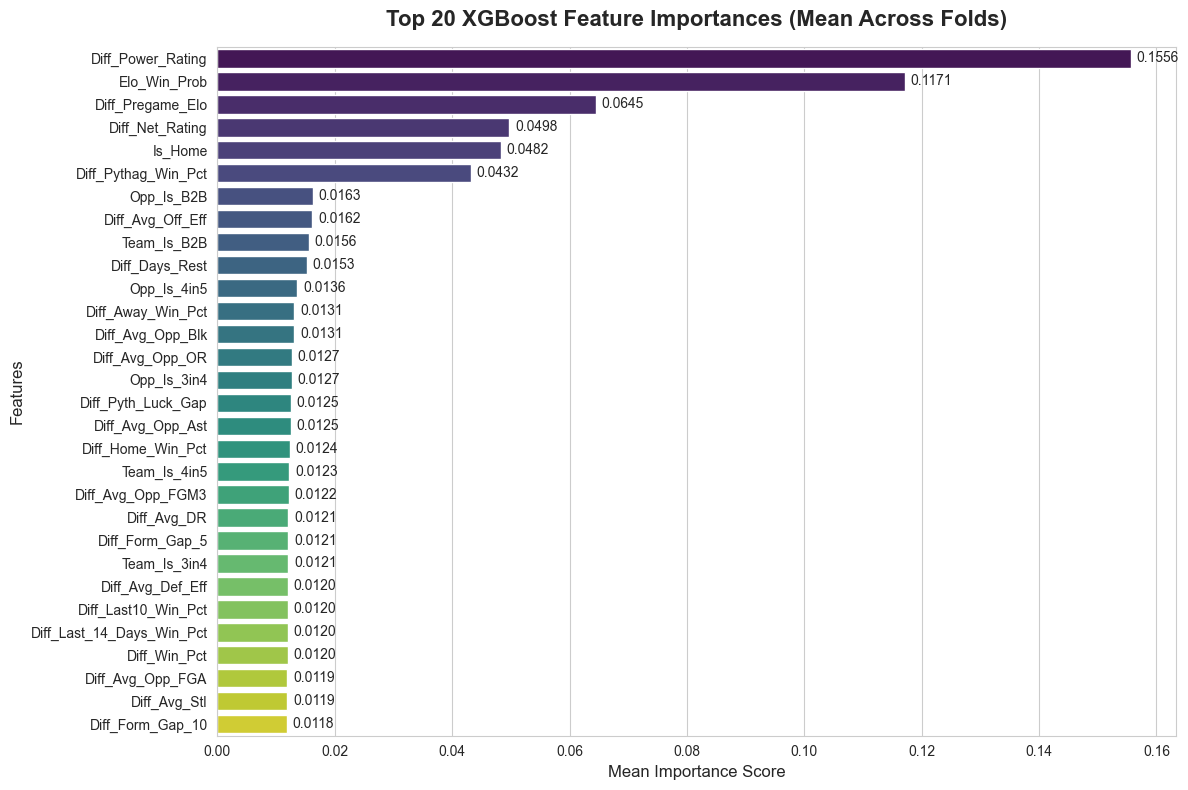

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

# ---- Top features by mean importance across folds ----
fi = pd.DataFrame({f'fold_{i}': m.feature_importances_ for i, m in enumerate(fold_models)},
                  index=feature_cols)
fi['mean'] = fi.mean(axis=1)
fi = fi.sort_values('mean', ascending=False)

# ----------------------------------------------------
# VISUALIZATION: Top 20 Features
# ----------------------------------------------------
# Reset index so the feature names become a standard column we can plot
top_features = fi.head(30).reset_index()
top_features = top_features.rename(columns={'index': 'Feature'})

# Set up the plot size and style
plt.figure(figsize=(12, 8))
sns.set_style("whitegrid") # Adds faint grid lines to make reading scores easier

# Create a horizontal bar chart
ax = sns.barplot(
    x='mean', 
    y='Feature', 
    data=top_features, 
    palette='viridis' # A clean, modern color gradient
)

# Formatting the chart
plt.title('Top 20 XGBoost Feature Importances (Mean Across Folds)', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Mean Importance Score', fontsize=12)
plt.ylabel('Features', fontsize=12)

# Optional: Add the exact score numbers to the end of each bar
for p in ax.patches:
    width = p.get_width()
    plt.text(width + 0.001, p.get_y() + p.get_height() / 2,
             f'{width:.4f}', 
             ha='left', va='center', fontsize=10)

# Adjust layout to fit long feature names and display
plt.tight_layout()
plt.show()

Original games: 23958
Clean games for LR: 22976 (Dropped 982 early-season rows)\n
--- EXACT LOGISTIC REGRESSION B VALUES ---
Diff_Last10_Win_Pct             -0.3005
Diff_Last5_Win_Pct              -0.2144
Diff_Pyth_Luck_Gap              -0.1161
Diff_Avg_FGM3                   -0.0992
Diff_Avg_Opp_Score              -0.0978
Team_Is_B2B                     -0.0978
Diff_Avg_Opp_Ast                -0.0889
Diff_Avg_Opp_Blk                -0.0782
Diff_Avg_Opp_FGA3               -0.0676
Diff_Avg_Opp_OR                 -0.0655
Diff_Avg_Score                  -0.0649
Diff_Net_Rating                 -0.0553
Team_Altitude_Dis               -0.0432
Diff_Avg_Opp_DR                 -0.0229
Diff_Avg_FTA                    -0.0217
Diff_Avg_FGA                    -0.0215
Diff_Avg_Opp_Stl                -0.0207
Team_Is_3in4                    -0.0178
Team_Is_4in5                    -0.0172
Diff_Win_Streak                 -0.0123
Diff_Avg_OR                     -0.0090
Diff_Avg_TO                     -0.

C:\Users\Furag\AppData\Local\Temp\ipykernel_2368\66188530.py:60: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='B_Value', y='Feature', data=coef_df, palette=colors)


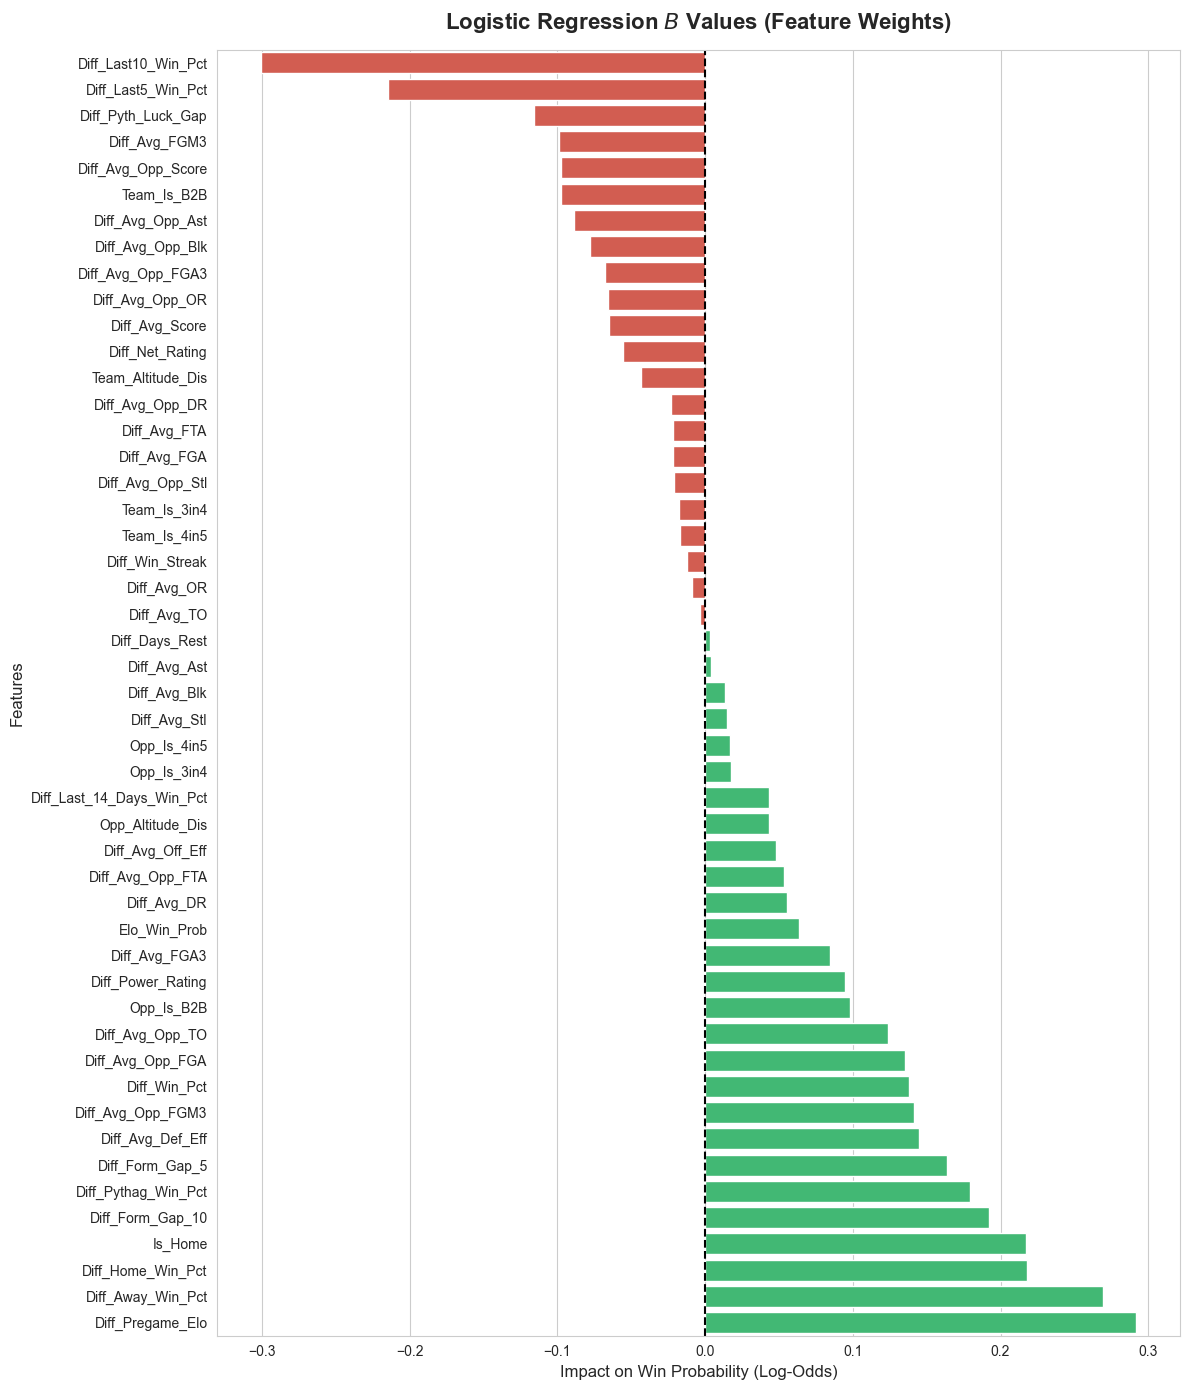

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

# ==========================================
# 1. LOAD AND CLEAN THE DATA
# ==========================================
df = pd.read_csv("matchups_v2.csv", parse_dates=['DayDate'])

# Logistic Regression CANNOT handle NaNs. We must drop the chaotic early-season games.
# (FEATURE_LIST was defined in your previous notebook cell)
clean_df = df.dropna(subset=FEATURE_LIST).copy()

X = clean_df[FEATURE_LIST]
y = clean_df['Target_Win'].astype(int)

print(f"Original games: {len(df)}")
print(f"Clean games for LR: {len(clean_df)} (Dropped {len(df) - len(clean_df)} early-season rows)\\n")

# ==========================================
# 2. SCALE THE FEATURES
# ==========================================
# We must scale the data so all B-values are on the same numerical playing field
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ==========================================
# 3. TRAIN THE MODEL & EXTRACT B VALUES
# ==========================================
# C=0.1 applies L2 regularization to keep correlated features from exploding
lr_model = LogisticRegression(max_iter=1000, C=0.1, random_state=42)
lr_model.fit(X_scaled, y)

# Extract the coefficients
b_values = lr_model.coef_[0]

# Map them to a DataFrame
coef_df = pd.DataFrame({
    'Feature': FEATURE_LIST,
    'B_Value': b_values
}).sort_values(by='B_Value', ascending=True)

# Print the exact mathematical weights
print("--- EXACT LOGISTIC REGRESSION B VALUES ---")
for index, row in coef_df.iterrows():
    print(f"{row['Feature']:<30s} {row['B_Value']:>8.4f}")

# ==========================================
# 4. VISUALIZE THE WEIGHTS
# ==========================================
plt.figure(figsize=(12, 14))
sns.set_style("whitegrid")

# Green for positive impact on winning, Red for negative impact
colors = ['#e74c3c' if x < 0 else '#2ecc71' for x in coef_df['B_Value']]

ax = sns.barplot(x='B_Value', y='Feature', data=coef_df, palette=colors)

plt.title('Logistic Regression $B$ Values (Feature Weights)', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Impact on Win Probability (Log-Odds)', fontsize=12)
plt.ylabel('Features', fontsize=12)

# Add a vertical center line
plt.axvline(0, color='black', linewidth=1.5, linestyle='--')

plt.tight_layout()
plt.show()